In [1]:
# All the physical features, and clinical scores

C:\Users\Abhineet Anand\AppData\Local\Temp\ipykernel_17904\393823119.py:13: DtypeWarning: Columns (19,20,21,50,51,104,105,106) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('adnimerge.csv')


Total Patient Records Retained: 11458

Training the Comprehensive Clinical Model... (This may take a moment)


C:\Users\Abhineet Anand\anaconda3\Lib\site-packages\xgboost\training.py:200: UserWarning: [00:20:46] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



--- Comprehensive Model Evaluation ---
Accuracy Score: 0.8887434554973822

Classification Report:
               precision    recall  f1-score   support

          CN       0.93      0.89      0.91       804
    Dementia       0.89      0.88      0.88       490
         MCI       0.86      0.90      0.88       998

    accuracy                           0.89      2292
   macro avg       0.89      0.89      0.89      2292
weighted avg       0.89      0.89      0.89      2292



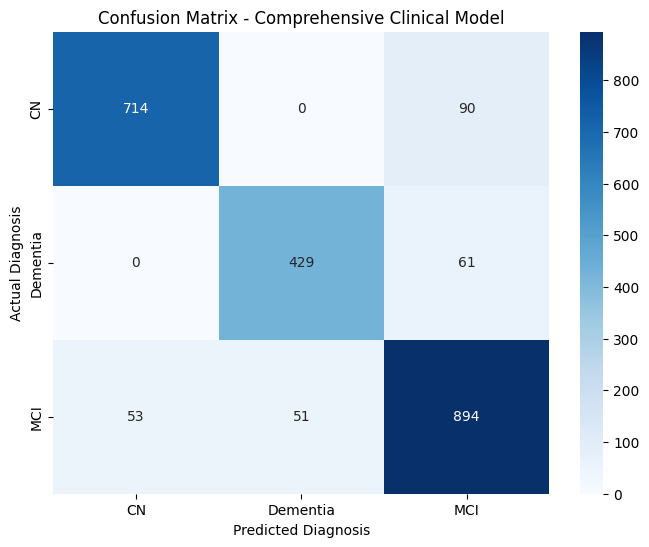

C:\Users\Abhineet Anand\AppData\Local\Temp\ipykernel_17904\393823119.py:109: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=importance_df, palette='magma')


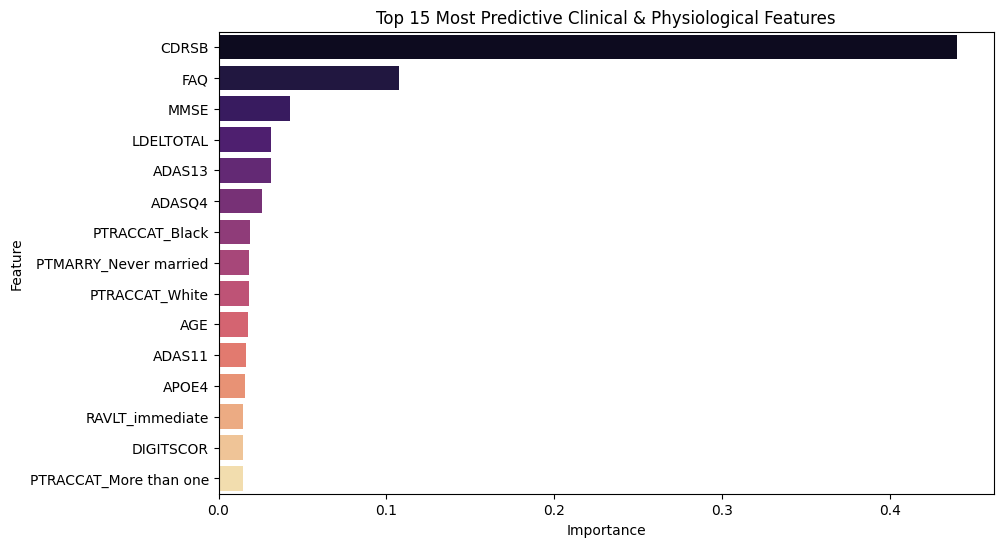

In [2]:
# The Comprehensive Clinical & Physiological Model
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import LabelEncoder
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load Data
# Replace 'adnimerge.csv' with your actual file path
df = pd.read_csv('adnimerge.csv')
target_col = 'DX'

# 2. Define the Ultimate Feature Set
demographic_physio = ['AGE', 'PTGENDER', 'PTEDUCAT', 'PTETHCAT', 'PTRACCAT', 'PTMARRY']
genetic = ['APOE4']
global_cognition = ['MMSE', 'CDRSB', 'MOCA']
adas_battery = ['ADAS11', 'ADAS13', 'ADASQ4']
ravlt_battery = ['RAVLT_immediate', 'RAVLT_learning', 'RAVLT_forgetting', 'RAVLT_perc_forgetting']
other_neuro_tests = ['LDELTOTAL', 'DIGITSCOR', 'TRABSCOR']
functional = ['FAQ']

all_features = demographic_physio + genetic + global_cognition + adas_battery + ravlt_battery + other_neuro_tests + functional

# 3. Subset Data and Drop Only Target NaNs
# We ONLY drop rows if the actual diagnosis (DX) is missing. 
# We keep all other missing test scores because XGBoost handles them natively!
df_omni = df[['RID', 'VISCODE', target_col] + all_features].copy()
df_omni = df_omni.dropna(subset=[target_col])

print(f"Total Patient Records Retained: {len(df_omni)}")

# 4. Handle Categorical / Text Variables
# Convert Gender to binary
df_omni['PTGENDER'] = df_omni['PTGENDER'].map({'Male': 0, 'Female': 1})

# Use One-Hot Encoding for text-based physiological categories (Race, Ethnicity, Marital)
# This turns categories like "Married" into columns with 0s and 1s
df_encoded = pd.get_dummies(df_omni, columns=['PTETHCAT', 'PTRACCAT', 'PTMARRY'], drop_first=True)

# Update our feature list to include the newly created dummy columns
features_encoded = [col for col in df_encoded.columns if col not in ['RID', 'VISCODE', target_col]]

# 5. Prepare X and y
X = df_encoded[features_encoded]
y = df_encoded[target_col]

# Encode Target Labels (CN->0, MCI->1, Dementia->2)
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

# 6. Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.20, random_state=42, stratify=y_encoded
)

# 7. Initialize the Comprehensive XGBoost Model
# Note: We do NOT scale the data. Trees don't need scaling, and it breaks NaN handling.
xgb_omni = XGBClassifier(
    n_estimators=300,          # More trees to handle the massive feature set
    max_depth=5,               # Slightly deeper trees for complex clinical interactions
    learning_rate=0.05, 
    subsample=0.8,             
    colsample_bytree=0.8,      # Randomly select 80% of features per tree to prevent overfitting
    eval_metric='mlogloss',
    use_label_encoder=False,
    missing=np.nan,            # Explicitly tell XGBoost how to handle blanks
    random_state=42
)

# 8. Train the Model
print("\nTraining the Comprehensive Clinical Model... (This may take a moment)")
xgb_omni.fit(X_train, y_train)

# 9. Predictions and Evaluation
y_pred_encoded = xgb_omni.predict(X_test)

# Convert numerical predictions back to clinical labels
y_pred_text = label_encoder.inverse_transform(y_pred_encoded)
y_test_text = label_encoder.inverse_transform(y_test)

# 10. Output Metrics
print("\n--- Comprehensive Model Evaluation ---")
print("Accuracy Score:", accuracy_score(y_test_text, y_pred_text))
print("\nClassification Report:\n", classification_report(y_test_text, y_pred_text))

# 11. Visualizations
# Plot Confusion Matrix
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test_text, y_pred_text, labels=label_encoder.classes_)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=label_encoder.classes_, 
            yticklabels=label_encoder.classes_)
plt.title('Confusion Matrix - Comprehensive Clinical Model')
plt.xlabel('Predicted Diagnosis')
plt.ylabel('Actual Diagnosis')
plt.show()

# Plot Top 15 Feature Importances
feature_importances = xgb_omni.feature_importances_
importance_df = pd.DataFrame({
    'Feature': features_encoded,
    'Importance': feature_importances
}).sort_values(by='Importance', ascending=False).head(15) # Show top 15

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=importance_df, palette='magma')
plt.title('Top 15 Most Predictive Clinical & Physiological Features')
plt.show()